In [ ]:
import pandas as pd

In [ ]:
dfath = pd.read_csv('/content/athlete_events.csv',sep=",")
dfnoc = pd.read_csv('/content/noc_regions.csv', sep=",")

In [ ]:
dfath.sample(5)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
212381,106632,Dietmar Schauerhammer,M,28.0,188.0,89.0,East Germany-1,GDR,1984 Winter,1984,Winter,Sarajevo,Bobsleigh,Bobsleigh Men's Four,Gold
141671,71069,Birgit Lohberg-Schulz,F,22.0,176.0,63.0,West Germany,FRG,1988 Summer,1988,Summer,Seoul,Swimming,Swimming Women's 200 metres Freestyle,NaN
174634,87720,Hans-Sigfrid Oberer,M,30.0,178.0,68.0,Switzerland,SUI,1964 Winter,1964,Winter,Innsbruck,Cross Country Skiing,Cross Country Skiing Men's 4 x 10 kilometres R...,NaN
6457,3619,Ioanna Anagnostopoulou,F,19.0,181.0,58.0,Greece,GRE,2016 Summer,2016,Summer,Rio de Janeiro,Rhythmic Gymnastics,Rhythmic Gymnastics Women's Group,NaN
160116,80345,Hryhoriy Anatoliyovych Misiutin,M,21.0,166.0,62.0,Unified Team,EUN,1992 Summer,1992,Summer,Barcelona,Gymnastics,Gymnastics Men's Rings,NaN


In [ ]:
dfath.shape ,dfnoc.shape

((271116, 15), (230, 3))

In [ ]:
dfnoc.sample(5)

,NOC,region,notes
50,CRO,Croatia,NaN
121,LTU,Lithuania,NaN
140,MTN,Mauritania,NaN
209,UAE,United Arab Emirates,NaN
110,KOS,Kosovo,NaN


In [ ]:
df = pd.merge(dfath,dfnoc ,how='left',on='NOC')
df.head(5)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN,Netherlands,NaN


In [ ]:
print(df.info(), df.shape)
df.isnull().sum()
df.drop(columns=['notes'], inplace=True)  # dropping notes columns as it has any null values

# select only summer olympics
df= df[df['Season']=='Summer']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 17 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
 15  region  270746 non-null  object 
 16  notes   5039 non-null    object 
dtypes: float64(3), int64(2), object(12)
memory usage: 35.2+ MB
None (271116, 17)


In [ ]:
df.duplicated().sum()

## Region is the actual country name but it has historic problem --> Soviet union now Russia, and many more

np.int64(1385)

In [ ]:
df.drop_duplicates(inplace= True)

In [ ]:
df.isnull().sum()

,0
ID,0
Name,0
Sex,0
Age,9030
Height,50500
Weight,52506
Team,0
NOC,0
Games,0
Year,0


In [ ]:
temp = df['Team'].apply(lambda x: x.split("/") ).reset_index()
temp
# temp['Team'].head(5)

,index,Team
0,0,[China]
1,1,[China]
2,2,[Denmark]
3,3,"[Denmark, Sweden]"
4,26,[Netherlands]
...,...,...
221162,271106,[Argentina]
221163,271107,[United States]
221164,271108,[Russia]
221165,271109,[Russia]


In [ ]:
from numpy import nan
# find muliple country in single country
temp = df['Team'].apply(lambda x: x.split("/") if len(x.split("/"))>1 else nan).reset_index()
temp['Team'].dropna()

,Team
3,"[Denmark, Sweden]"
17225,"[Pistoja, Firenze]"
20426,"[Great Britain, Germany]"
31479,"[Barion, Bari-2]"
35055,"[Barion, Bari-2]"
35058,"[Pistoja, Firenze]"
42436,"[United States, France]"
43845,"[United States, France]"
45909,"[Barion, Bari-2]"
47448,"[United States, Great Britain]"


# making condition based new columns

1. np.where(codition , val if true, val if false)--> simple If-else
    df["Salary_Flag"] = np.where(
        df["Salary"] > df.groupby("Department")["Salary"].transform("mean"),
        "Above Avg",
        "Below Avg"
    )
  
2. get_dummies --> for categorical columns

    medal_cols = pd.get_dummies(df["Medal"])

    df = pd.concat([df, medal_cols], axis=1)

3. loc --> conditional updates

    df['new_column'] = randomval   --> else NAN will be present for non matching val

    df.loc[condition, new_column] = value

In [ ]:
import numpy as np

df = pd.concat([df,pd.get_dummies(df['Medal'], dtype=int)], axis=1)

# df['Gold'] = np.where(df['Medal']=='Gold', 1,0)
# df['Silver'] = np.where(df['Medal']=='Silver',1,0)
# df['Bronze'] = np.where(df['Medal'] == 'Bronze',1,0)

# df['Gold_custom'] = np.where(df['Medal'] == 'Gold', 'Yes', 'No')
# df['Silver_custom'] = np.where(df['Medal'] == 'Silver', 'Yes', 'No')
# df['Bronze_custom'] = np.where(df['Medal'] == 'Bronze', 'Yes', 'No')


# df['Gold']=0
# df['Silver']=0
# df['Bronze']=0
# df.loc[df['Medal']=='Gold', 'Gold'] =1
# df.loc[df['Medal']=='Silver','Silver'] = 1
# df.loc[df['Medal'] == 'Bronze','Bronze'] =1


# df['Gold'] = (df['Medal']=='Gold').astype(int)
# df['Silver'] = (df['Medal']=='Silver').astype(int)
# df['Bronze'] = (df['Medal'] == 'Bronze').astype(int)

# df['Gold1']= df['Medal'].apply(lambda x: 1 if x=='Gold' else 0)
# df = df[df['Gold'] != df['Gold1']]

df.head(5)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,Bronze,Gold,Silver
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,0,0,0
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,0,0,0
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,0,0,0
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,0,1,0
26,8,"Cornelia ""Cor"" Aalten (-Strannood)",F,18.0,168.0,NaN,Netherlands,NED,1932 Summer,1932,Summer,Los Angeles,Athletics,Athletics Women's 100 metres,NaN,Netherlands,0,0,0


In [ ]:
# tem = df[(df['NOC']=="SWE") & (df['Sport']=="Gymnastics") & (df['Year']==1908)]   # required in case of transform

# tem[['gold1','silver1','bronz1']] = df[(df['NOC']=="SWE") & (df['Sport']=="Gymnastics") & (df['Year']==1908)].groupby(['NOC','Year','Sport','Event','Team','Medal'],as_index=False)[['Gold','Silver','Bronze']].transform('mean')
tem = df[(df['NOC']=="SWE") & (df['Sport']=="Gymnastics") & (df['Year']==1908)].groupby(['NOC','Year','Sport','Event','Team','Medal'],as_index=False)[['Gold','Silver','Bronze']].sum()
# tem[['NOC','Year','Sport','Event','Team','Medal','Gold','Silver','Bronze','gold1','silver1','bronz1']]

tem[['NOC','Year','Sport','Event','Team','Medal','Gold','Silver','Bronze']]

,NOC,Year,Sport,Event,Team,Medal,Gold,Silver,Bronze
0,SWE,1908,Gymnastics,Gymnastics Men's Team All-Around,Sweden,Gold,38,0,0


## drop_duplicates(subsets=[]) --> will drop duplicates rows based on columns given in subsets.

df.drop_duplicates(subset=['Team', 'NOC', 'Games', 'Year', 'City', 'Sport', 'Event', 'Medal'])

This is important b/z we can retain all the columns but when we groupby to simulates similar condition then we loose columns not used in groupby.

in current case better to show the medal_tallly countrywise rather than NOC wise. But same country are having multiple NOC due to historical name changes.

In [ ]:
new_medal_tally = df.drop_duplicates(subset=['NOC','Year','Sport','Event','Team','Medal'])
new_medal_tally = new_medal_tally.groupby(['region'],as_index=False)[['Gold','Silver','Bronze']].sum().sort_values(['Gold'], ascending=False)
new_medal_tally   # similar result as shown below by NOC but with reduced complexity and code

,region,Gold,Silver,Bronze
191,USA,1035,802,708
151,Russia,592,498,487
67,Germany,444,457,491
190,UK,278,317,300
63,France,234,256,287
...,...,...,...,...
197,Vanuatu,0,0,0
200,"Virgin Islands, British",0,0,0
201,"Virgin Islands, US",0,1,0
202,Yemen,0,0,0


In [ ]:
medal_tally = df.groupby(['NOC','Year','Sport','Event','Team','Medal'], as_index=False)['Gold'].mean().sort_values(['Gold'], ascending= False)
medal_tally

,NOC,Year,Sport,Event,Team,Medal,Gold
16043,YUG,1984,Handball,Handball Men's Handball,Yugoslavia,Gold,1.0
16044,YUG,1984,Handball,Handball Women's Handball,Yugoslavia,Gold,1.0
16058,YUG,1988,Shooting,"Shooting Women's Air Pistol, 10 metres",Yugoslavia,Gold,1.0
16057,YUG,1988,Shooting,"Shooting Men's Air Rifle, 10 metres",Yugoslavia,Gold,1.0
16046,YUG,1984,Water Polo,Water Polo Men's Water Polo,Yugoslavia,Gold,1.0
...,...,...,...,...,...,...,...
16056,YUG,1988,Rowing,Rowing Men's Coxless Pairs,Yugoslavia,Bronze,0.0
11,ALG,2000,Athletics,Athletics Men's 800 metres,Algeria,Bronze,0.0
12,ALG,2000,Athletics,Athletics Men's High Jump,Algeria,Bronze,0.0
14,ALG,2000,Boxing,Boxing Men's Light-Welterweight,Algeria,Bronze,0.0


In [ ]:
## Region is the actual country name but it has historic problem --> Soviet union now Russia, and many more so will use NOC

# Below analysis is wrong. The data is at athelit level in case of team event if team won then all athelics will wons, increaing the no of medal


# medal_tally = df.groupby(['NOC','Year','Sport','Event','Team','Medal'], as_index=False)[['Gold','Silver','Bronze']].mean().sort_values(['Gold'], ascending=False).reset_index()
medal_tally = df.groupby(['NOC','Year','Sport','Event','Team','Medal'], as_index=False).agg(Gold=('Gold','mean'),Silver=('Silver','mean'),Bronze=('Bronze','mean')).sort_values(['Gold'], ascending=False).reset_index()

display(medal_tally[(medal_tally['Gold'].astype(int) > 1) | ((medal_tally['Gold'].astype(int) < 1) & (medal_tally['Gold'].astype(int) > 0))])
print("above result for fraction medal if present")
print()

# medal_tally.sample(5)
medal_tally[~ medal_tally['Medal'].isin(['Gold','Silver','Bronze'])]

,index,NOC,Year,Sport,Event,Team,Medal,Gold,Silver,Bronze


above result for fraction medal if present



,index,NOC,Year,Sport,Event,Team,Medal,Gold,Silver,Bronze


In [ ]:
# checking the effect of groupby on Nan --> will not be included

df.groupby(['Medal'])['Medal'].value_counts(), df['Medal'].value_counts()

(Medal
 Bronze    11409
 Gold      11456
 Silver    11212
 Name: count, dtype: int64,
 Medal
 Gold      11456
 Bronze    11409
 Silver    11212
 Name: count, dtype: int64)

In [ ]:
medal_tally = medal_tally.groupby(['NOC'],as_index=False)[['Gold','Silver','Bronze']].sum(). sort_values(['Gold'], ascending=False).set_index('NOC')
medal_tally['Gold'] = medal_tally['Gold'].astype(int)
medal_tally['Silver'] = medal_tally['Silver'].astype(int)
medal_tally['Bronze'] = medal_tally['Bronze'].astype(int)
medal_tally



,Gold,Silver,Bronze
NOC,,,
USA,1035,802,708
URS,394,317,294
GBR,278,317,300
GER,235,261,283
FRA,234,256,287
...,...,...,...
SRI,0,2,0
SUD,0,1,0
UAR,0,1,1


In [ ]:
medal_tally.loc[["YUG"]], medal_tally.shape

(     Gold  Silver  Bronze
 NOC                      
 YUG    26      29      28,
 (147, 3))

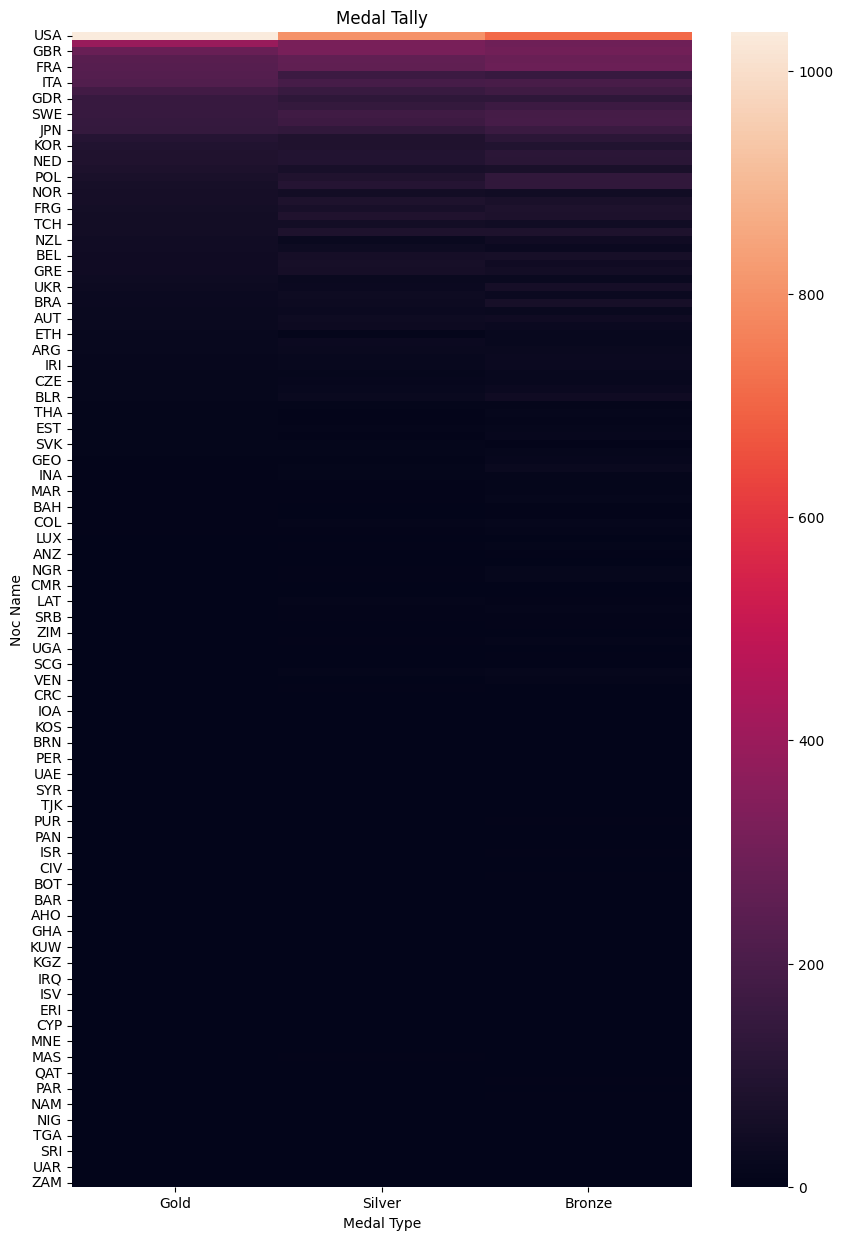

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig,axes = plt.subplots(1,1, figsize=(10,15))
# plt.figure(figsize=(10,10))
# sns.heatmap(medal_tally )

# the below code for labels will not work b/z that is property of axis

# sns.set_xlabel("Medal Type")
# sns.set_ylabel("Noc Name")
# sns.set_title("Medal Tally")

sns.heatmap(medal_tally, ax = axes)
axes.set_xlabel("Medal Type")
axes.set_ylabel("Noc Name")
axes.set_title("Medal Tally")
plt.show()


using sort directly while assigning will not work as it does not return so years = NONE. Sort modify in place

years = df['Yeat'].unique().sort()

In [ ]:
years = df['Year'].unique().tolist() # default it will be numpy.ndarray in which we cannot use list functions
years.sort()
years.insert(0,'All') # only after sorting else mismatch in datatype
years[0:5]

['All', 1896, 1900, 1904, 1906]

In [ ]:
country = df['region'].unique()

# country.sort()  # nan is present which is giving error while sorting
print("issue in sorting is - ",[ val for val in country if not(isinstance(val,str))])

country = df['region'].dropna().unique().tolist()   #default it will be numpy.ndarray in which we cannot use list functions
country.sort()
country.insert(0,'overall')
country[0:10]

issue in sorting is -  [nan]


['overall',
 'Afghanistan',
 'Albania',
 'Algeria',
 'American Samoa',
 'Andorra',
 'Angola',
 'Antigua',
 'Argentina',
 'Armenia']

In [ ]:
# df
df['Year'].unique().shape[0], df['Sport'].unique().shape[0], df['City'].unique().shape[0],df['region'].unique().shape[0], df['Name'].unique().shape[0]

(29, 52, 23, 206, 116122)

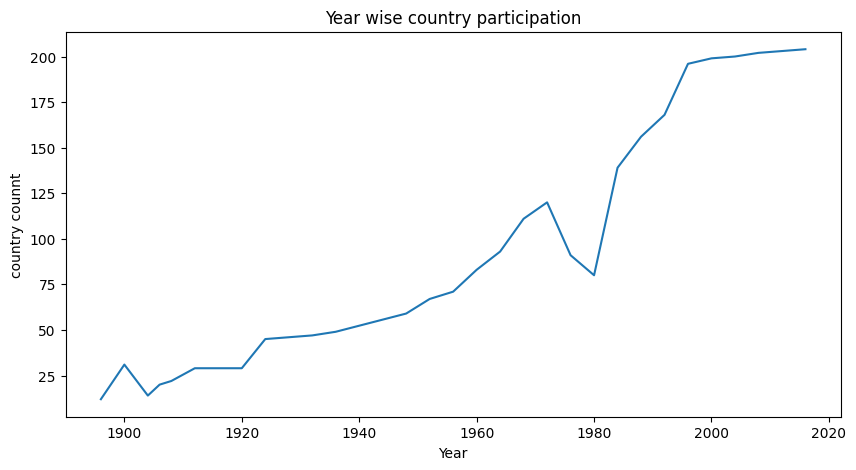

In [ ]:
# yearwise_df = df.drop_duplicates(subset=['NOC','Year','Sport','Event','Team','Medal'])
yearwise_df = df.drop_duplicates(subset=['Year','region'])
# yearwise_df = yearwise_df.groupby(['Year'], as_index=False).apply(lambda x: x['region'].unique().shape[0])
yearwise_df = yearwise_df['Year'].value_counts().reset_index().sort_values(['Year'], ascending=True)
# yearwise_df.rename(columns=({None:'count'}), inplace=True)
# display(yearwise_df)

fig, subaxis = plt.subplots(1,1,figsize=(10,5))
sns.lineplot(x= yearwise_df['Year'], y=yearwise_df['count'],ax = subaxis)
subaxis.set_xlabel('Year')
subaxis.set_ylabel('country counnt')
subaxis.set_title('Year wise country participation')
plt.show()


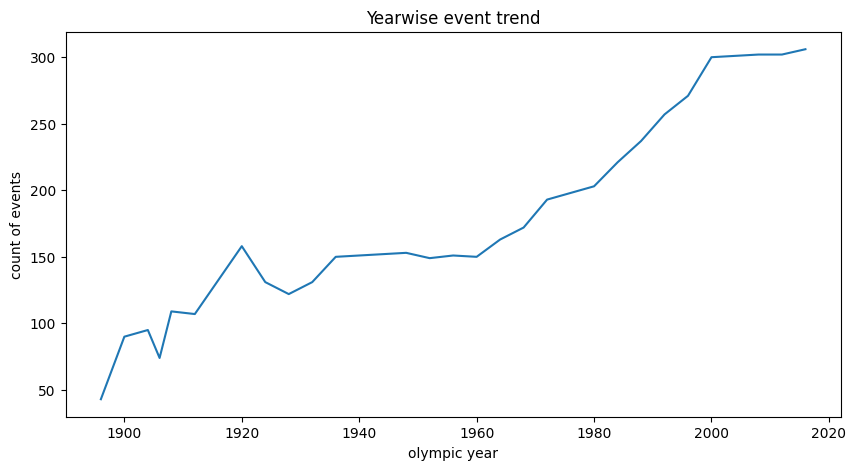

In [ ]:
eventwise_df = df.drop_duplicates(subset=['Year','Event'])
# eventwise_df = eventwise_df.groupby(['Year'])['Event'].count()
eventwise_df = eventwise_df['Year'].value_counts().reset_index()
eventwise_df

fig,axes = plt.subplots(1,1,figsize=(10,5))
sns.lineplot(x=eventwise_df['Year'],y=eventwise_df['count'], ax=axes)
axes.set_xlabel('olympic year')
axes.set_ylabel('count of events')
axes.set_title('Yearwise event trend')
plt.show()


,Year,count
0,2016,11216
1,2008,10972
2,2000,10703
3,2004,10636
4,2012,10561
5,1996,10397
6,1992,9430
7,1988,8474
8,1972,7107
9,1984,6794


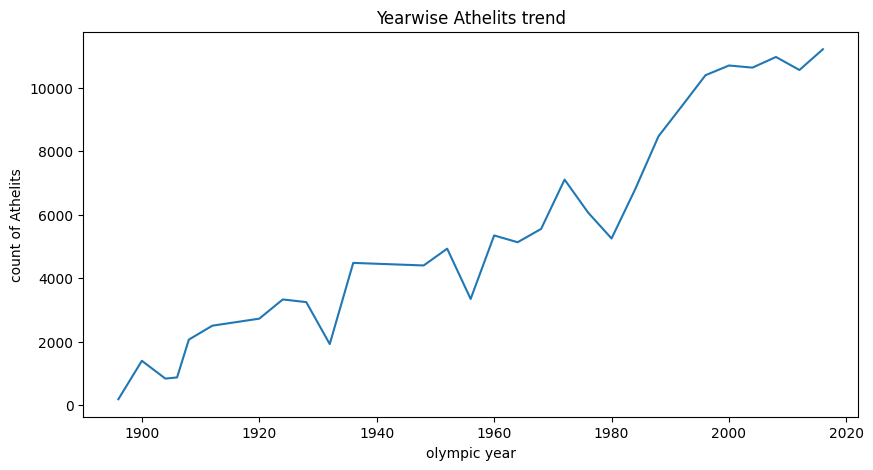

In [ ]:
new_df = df
new_df['NOC'] = new_df['NOC'].astype(str)


# since data is athelitc wise in each year so grouping by year,id and then finding their name will be accurate
athelitwise_df = new_df.drop_duplicates(subset=['Year','Name', 'Team','NOC'])
athelitwise_df = athelitwise_df['Year'].value_counts().reset_index()
display(athelitwise_df[0:10])


fig,axes = plt.subplots(1,1,figsize=(10,5))
sns.lineplot(x=athelitwise_df['Year'],y=athelitwise_df['count'], ax=axes)
axes.set_xlabel('olympic year')
axes.set_ylabel('count of Athelits')
axes.set_title('Yearwise Athelits trend')
plt.show()


In [ ]:
# trying athelitc wise by grouping by id then joing with their name

temp = df.drop_duplicates(subset=['Year','ID'])
temp['Year'].value_counts().reset_index()[0:10]

# as you can see the athelitic count no are a bit differnt from above. Here we excluded people with same name in same Year by droping by "ID"

,Year,count
0,2016,11179
1,2008,10899
2,2000,10647
3,2004,10557
4,2012,10517
5,1996,10339
6,1992,9386
7,1988,8454
8,1972,7114
9,1984,6798


In [ ]:
sportwise_event = df.drop_duplicates(subset=['Year','Sport','Event'])
sportwise_event.head(2)

sportwise_event = sportwise_event.groupby(['Year','Sport'],as_index=False)['Event'].count().sort_values(['Event'],ascending = False)
sportwise_event

# sns.heatmap(x=sportwise_event['year'], y=sportwise_event['sport'], annot= True)

,Year,Sport,Event
639,2016,Athletics,47
573,2008,Athletics,47
607,2012,Athletics,47
539,2004,Athletics,46
505,2000,Athletics,46
...,...,...,...
300,1964,Water Polo,1
43,1904,Tug-Of-War,1
44,1904,Water Polo,1
17,1900,Football,1


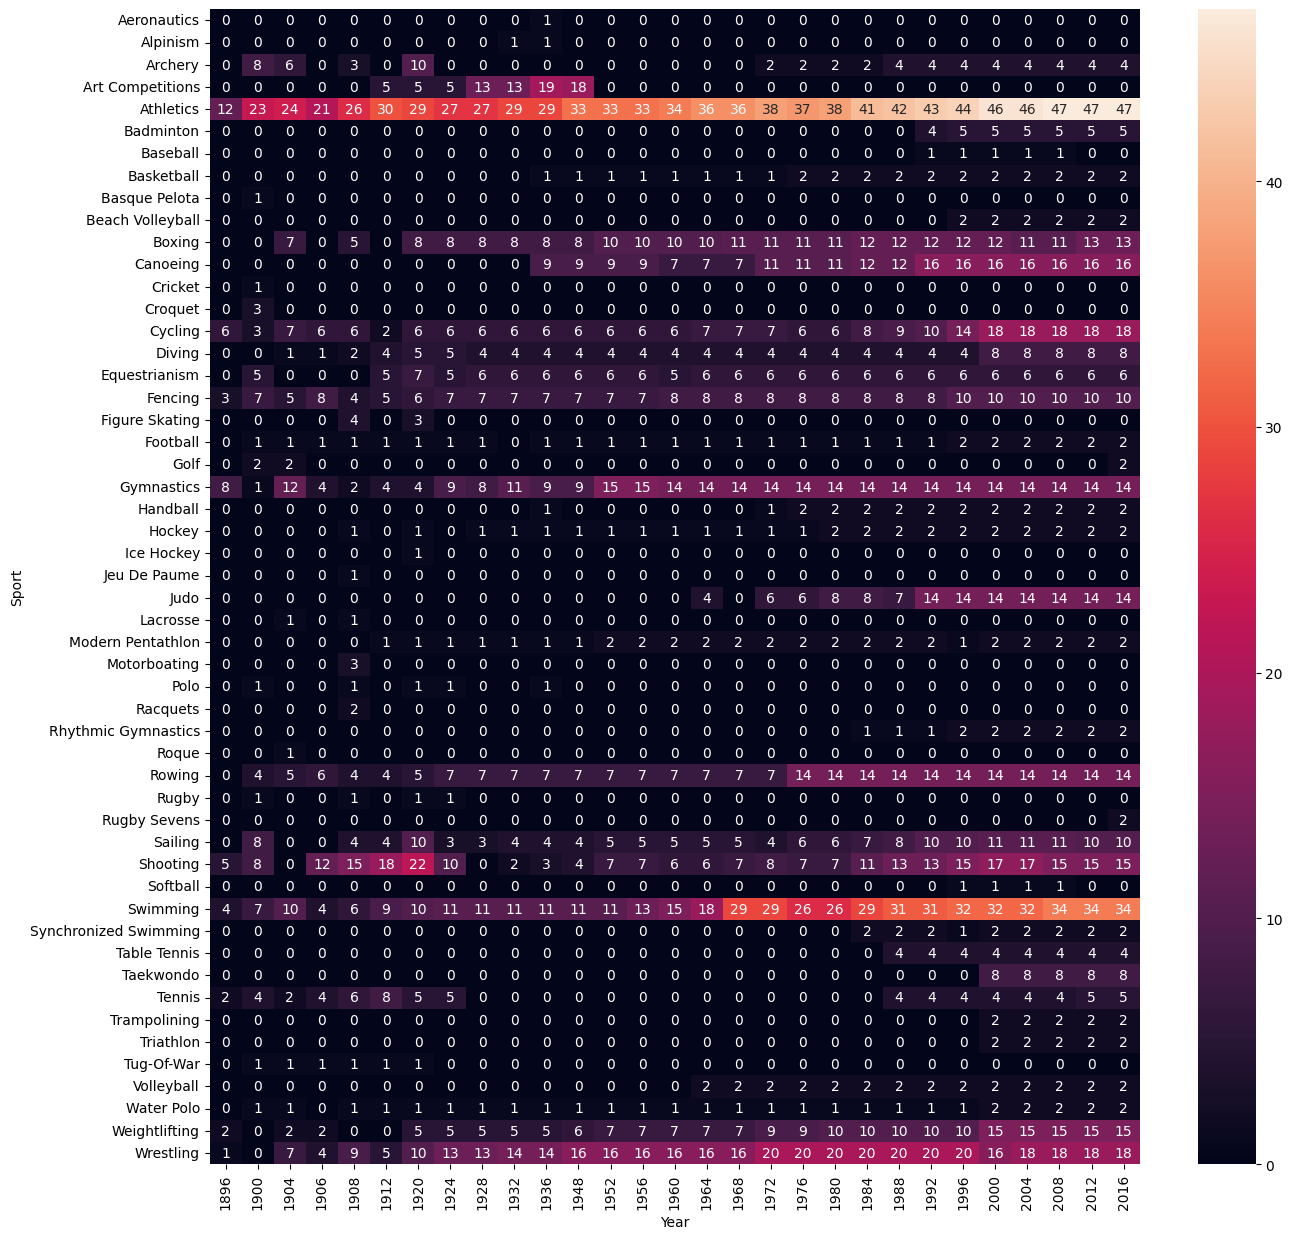

In [ ]:
sportwise_event = df.drop_duplicates(subset=['Year','Sport','Event'])
# sportwise_event = sportwise_event.groupby(['Year','Sport'], as_index=False)['Event'].count().sort_values(['Event'], ascending=False)
sportwise_event = pd.pivot_table(sportwise_event,index='Sport' ,columns='Year',values='Event', aggfunc='count',fill_value=0).astype(int)
sportwise_event

plt.figure(figsize=(15,15))
sns.heatmap(sportwise_event, annot= True)
plt.show()

In [ ]:
# most successful athelits --> remove without medal and count people with same name but for different country.

successful_athelits = df.dropna(subset=['Medal'])

# same/different person with same name can win multiple event in same year so not applicable the below line
# successful_athelits = successful_athelits.drop_duplicates(subset=['Year','ID'])

# successful_athelits = successful_athelits.drop_duplicates()  # no dulicates for entire columns
# successful_athelits = successful_athelits[['Year','ID']].value_counts()
successful_athelits = successful_athelits.groupby(['ID','Name','Sport'], as_index=False)[['Gold','Silver','Bronze']].sum().sort_values(['Gold'], ascending=False)
successful_athelits

# assuming 1 athelic can win multiple sport/event

,ID,Name,Sport,Gold,Silver,Bronze
16934,94406,"Michael Fred Phelps, II",Swimming,23,3,2
5785,33557,"Raymond Clarence ""Ray"" Ewry",Athletics,10,0,0
12036,67046,Larysa Semenivna Latynina (Diriy-),Gymnastics,9,5,4
12415,69210,"Frederick Carlton ""Carl"" Lewis",Athletics,9,1,0
20458,113912,Mark Andrew Spitz,Swimming,9,1,1
...,...,...,...,...,...,...
14,67,Mariya Vasilyevna Abakumova (-Tarabina),Athletics,0,1,0
13,65,Patimat Abakarova,Taekwondo,0,0,1
12,63,Jos Luis Abajo Gmez,Fencing,0,0,1
11,62,Giovanni Abagnale,Rowing,0,0,1
